# Tests Rapides de Modèles from scratch

Prototypage et tests initiaux de différents modèlessur un sous-ensemble de données (en local)

## Modèle Baseline : CNN simple from scratch  

Pour notre modèle baseline, nous allons implémenter un CNN simple from scratch

### 🔗 Références  lecture :  
1. [Définition du Deep Learning](https://datascientest.com/deep-learning-definition)  
2. [Initiation au CNN](https://datascientest.com/convolutional-neural-network)
2. [Tutoriel CNN avec TensorFlow](https://www.tensorflow.org/tutorials/images/cnn?hl=fr)   
5. [Livre sur le Deep Learning](https://rtavenar.github.io/deep_book/fr/content/fr/mlp.html)

### 🔗 Références Videos :  
1. [Initiation theorique au deep-leaning](https://www.youtube.com/watch?v=iUGTPcyYCPM&t)  
2. [suite initiation theorique intro CNN 1](https://www.youtube.com/watch?v=581X9wsnWJs)
2. [theorique  CNN 2 + tensorflow ](https://www.youtube.com/watch?v=zPwQiZFrwUY)
2. [Science4All CNN](https://www.youtube.com/watch?v=zG_5OtgxfAg)  
3. [Introduction aux CNN avec TensorFlow](https://www.datacamp.com/fr/tutorial/cnn-tensorflow-python)  
4. [CNN avec dataset local + explication detaillé du code](https://www.youtube.com/watch?v=s2jM15YenvA)  

## 1.Import des packages

In [29]:
import psutil
import tensorflow as tf
from tensorflow.keras import layers

import sys,os
# Ajouter src au chemin de recherche des modules
notebook_dir = os.getcwd()
src_path = os.path.abspath(os.path.join(notebook_dir, '..', 'src'))
if src_path not in sys.path:
	sys.path.append(src_path)
import image_search
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc


In [6]:
print("version tensorflow: {}".format(tf.__version__))
print("Mémoire totale :", psutil.virtual_memory().total / (1024**3), "GB")
print("Utilisation CPU :", psutil.cpu_percent(interval=1), "%")

for disk in psutil.disk_partitions():
    print("Type :", disk.fstype)
    print("Monté sur :", disk.mountpoint)
    print("-" * 30)

version tensorflow: 2.19.0
Mémoire totale : 7.605487823486328 GB
Utilisation CPU : 3.1 %
Type : ext4
Monté sur : /vscode
------------------------------
Type : ext4
Monté sur : /etc/resolv.conf
------------------------------
Type : ext4
Monté sur : /etc/hostname
------------------------------
Type : ext4
Monté sur : /etc/hosts
------------------------------


## Un reseau de neurone dense 
ref : [Tutoriel tensorflow](https://www.tensorflow.org/tutorials/keras/classification?hl=fr)

### 1. changement des images : 10 races

In [8]:
images_dir = '../data/images_transf_256x256'  
list_dir = '../data/lists'  

df_train, df_test = image_search.load_train_test_split_mat(
    images_dir=images_dir,
    list_dir=list_dir,
    max_races=10
)


En local nous allons travailler avec 40 races puis switcher vers Google Colab pour le cas général

### 2. Conversion en tableaux NumPy

In [9]:
X_train, y_train = image_search.images_to_numpy(df_train)
X_test, y_test = image_search.images_to_numpy(df_test)


In [10]:
print(f"X_train shape: {X_train.shape}, dtype: {X_train.dtype}")
print(f"X_test shape: {X_test.shape}, dtype: {X_test.dtype}")


X_train shape: (1000, 256, 256, 3), dtype: uint8
X_test shape: (919, 256, 256, 3), dtype: uint8


In [11]:
print(f"y_test shape: {y_test.shape}, \n unique classes:\n {np.unique(y_test)}")

y_test shape: (919,), 
 unique classes:
 ['n02085620-Chihuahua' 'n02085782-Japanese_spaniel'
 'n02085936-Maltese_dog' 'n02086079-Pekinese' 'n02086240-Shih-Tzu'
 'n02086646-Blenheim_spaniel' 'n02086910-papillon' 'n02087046-toy_terrier'
 'n02087394-Rhodesian_ridgeback' 'n02088094-Afghan_hound']


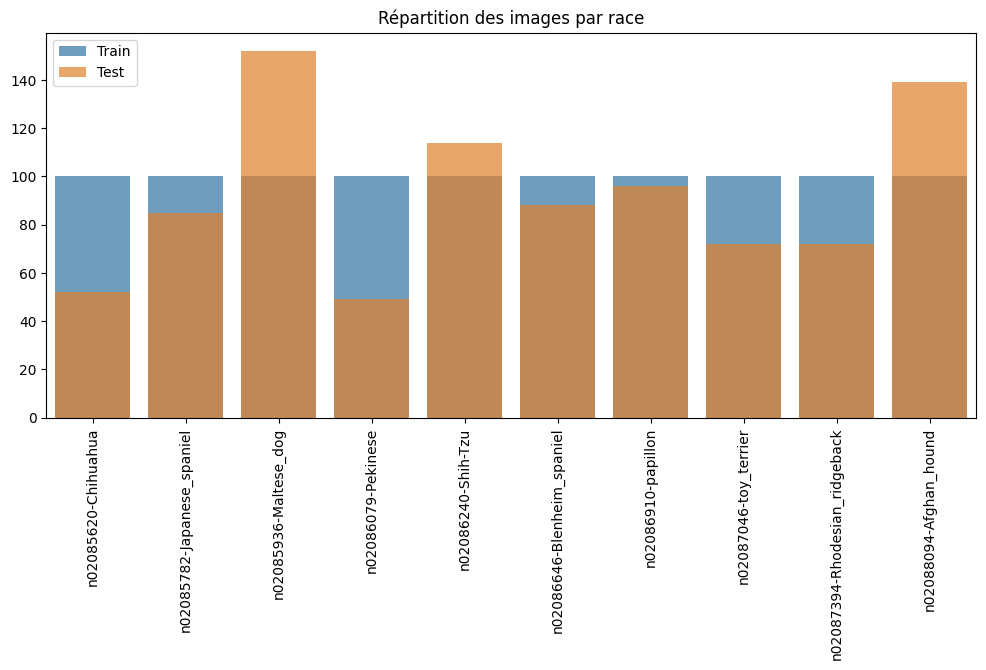

In [12]:
train_counts = {cls: sum(y_train == cls) for cls in np.unique(y_train)}
test_counts = {cls: sum(y_test == cls) for cls in np.unique(y_test)}
plt.figure(figsize=(12, 5))
sns.barplot(x=list(train_counts.keys()), y=list(train_counts.values()), alpha=0.7, label="Train")
sns.barplot(x=list(test_counts.keys()), y=list(test_counts.values()), alpha=0.7, label="Test")
plt.xticks(rotation=90)
plt.legend()
plt.title("Répartition des images par race")
plt.show()

Chaque race de chien dispose de 100 images dans le train, on peut donc faire nos modeles sans se soucier d'un eventuel desequilibre

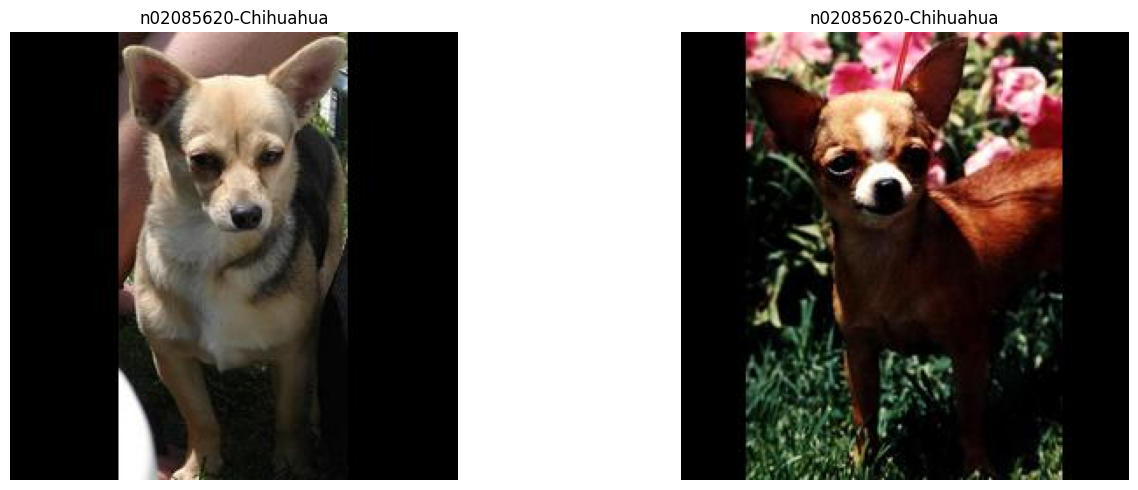

In [25]:
df_imgs=image_search.index_dataset(images_dir)
image_search.show_images(df_imgs,max_images=2)

### 3. Encodage des labels

In [13]:
# Conversion des labels en int
# LabelEncoder assigne un numéro unique à chaque classe
label_encoder = sklearn.preprocessing.LabelEncoder()
y_train_int = label_encoder.fit_transform(y_train)
y_test_int = label_encoder.transform(y_test)

# Transformation des labels entiers en représentation one-hot
# Nécessaire pour  softmax en sortie
# Format one-hot : [1, 0, 0] = classe 0, [0, 1, 0] = classe 1, etc.

y_train_cat = tf.keras.utils.to_categorical(y_train_int)
y_test_cat = tf.keras.utils.to_categorical(y_test_int)


In [14]:
print(f"y_train_int: {y_train_int[:10]}")  
print(f"y_train_cat shape: {y_train_cat.shape} \n \n")  
print(f"class 0 : {y_train_cat[0]}")

y_train_int: [0 0 0 0 0 0 0 0 0 0]
y_train_cat shape: (1000, 10) 
 

class 0 : [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


### Normalisation des pixels entre 0 et 1

In [15]:
X_train = X_train / 255
X_test = X_test / 255


In [18]:

model = tf.keras.models.Sequential([
    layers.Flatten(input_shape=X_train.shape[1:]),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(len(label_encoder.classes_), activation='softmax')
])


c:\Users\HP\Desktop\temp\Projet\Machine_Learning2\projet\env\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Couche Flatten : aplatie chaque image d'entrée 3D en un vecteur 1D


In [ ]:

model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Optimiseur : adam
    # - Il ajuste automatiquement le taux d'apprentissage pendant l'entraînement.
# Fonction de perte : categorical_crossentropy
    # - Compare la distribution prédite (softmax) à la distribution réelle (one-hot)


La perte categorical_crossentropy mesure l'écart entre les prédictions et les vraies classes


In [ ]:
history = model.fit(
    X_train, y_train_cat,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test_cat)
)


Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 549ms/step - accuracy: 0.1036 - loss: 48.5261 - val_accuracy: 0.1338 - val_loss: 15.0977
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 237ms/step - accuracy: 0.1628 - loss: 10.7252 - val_accuracy: 0.1360 - val_loss: 10.1898
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 243ms/step - accuracy: 0.1877 - loss: 7.0381 - val_accuracy: 0.1730 - val_loss: 5.1434
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 245ms/step - accuracy: 0.2808 - loss: 4.0601 - val_accuracy: 0.1545 - val_loss: 7.8618
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step - accuracy: 0.2594 - loss: 5.2641 - val_accuracy: 0.2405 - val_loss: 4.5662
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 215ms/step - accuracy: 0.3621 - loss: 2.9739 - val_accuracy: 0.2078 - val_loss: 5.1810
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 232ms/step - accuracy: 0.3555 - loss: 3.1391 - val_accuracy: 0.1806 - val_loss: 5.3954
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 231ms/step - accuracy: 0.4035 - loss: 3.0812 - val_accurac

In [21]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=2)
print(f"Test accuracy: {test_acc:.2%}")


29/29 - 1s - 32ms/step - accuracy: 0.1469 - loss: 5.7013
Test accuracy: 14.69%


In [28]:
# Prédictions du modèle
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convertir les probabilités en classes
y_true_classes = np.argmax(y_test_cat, axis=1)  # Convertir les labels one-hot en classes

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step


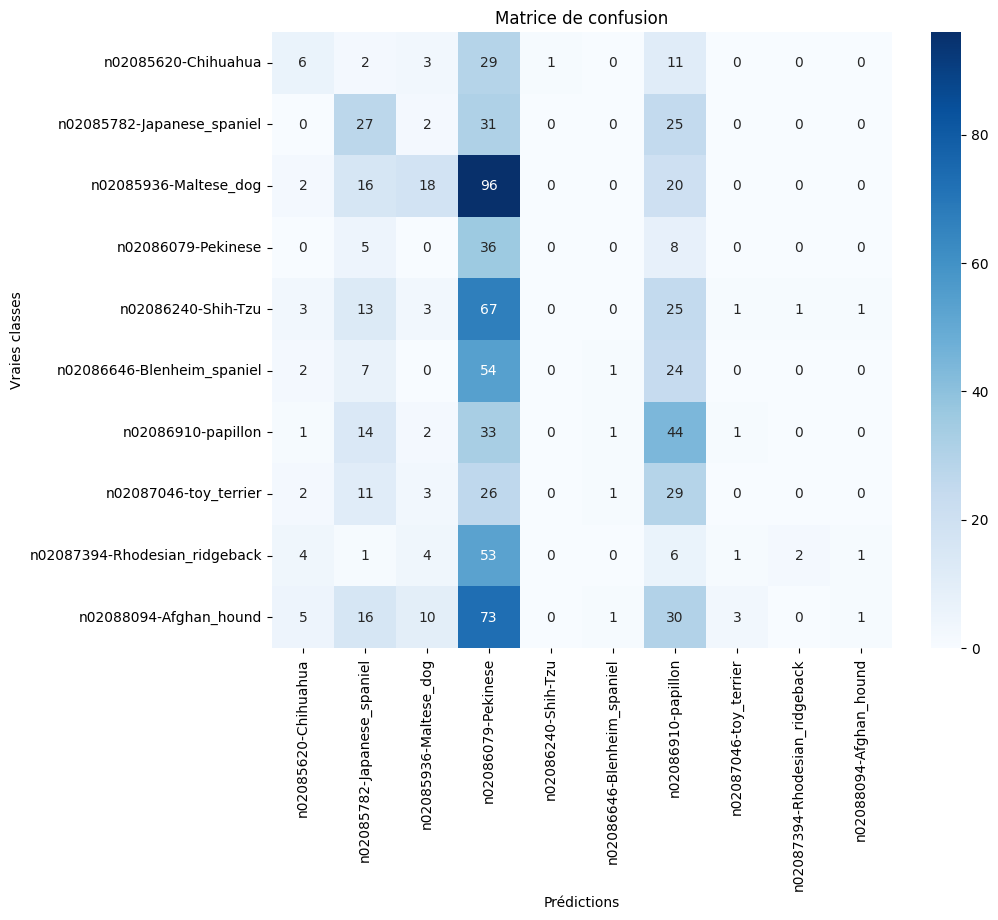

In [ ]:

# Calcul de la matrice de confusion
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Prédictions")
plt.ylabel("Vraies classes")
plt.title("Matrice de confusion")
plt.show()

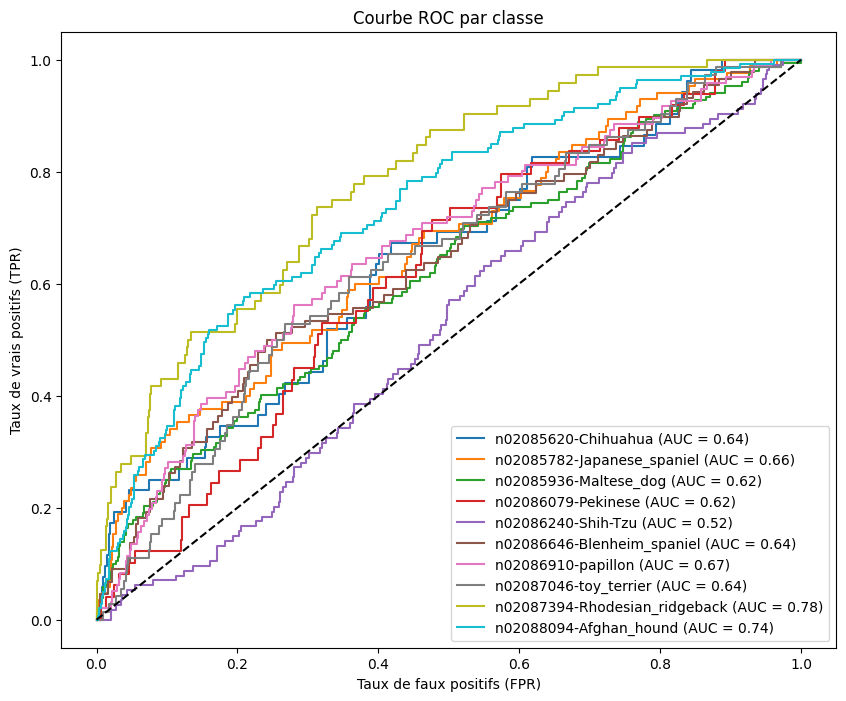

In [30]:
#Courbe de ROC
plt.figure(figsize=(10, 8))
for i in range(y_test_cat.shape[1]):  # Pour chaque classe
    fpr, tpr, _ = roc_curve(y_test_cat[:, i], y_pred[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{label_encoder.classes_[i]} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')  # Ligne de référence
plt.xlabel("Taux de faux positifs (FPR)")
plt.ylabel("Taux de vrais positifs (TPR)")
plt.title("Courbe ROC par classe")
plt.legend()
plt.show()

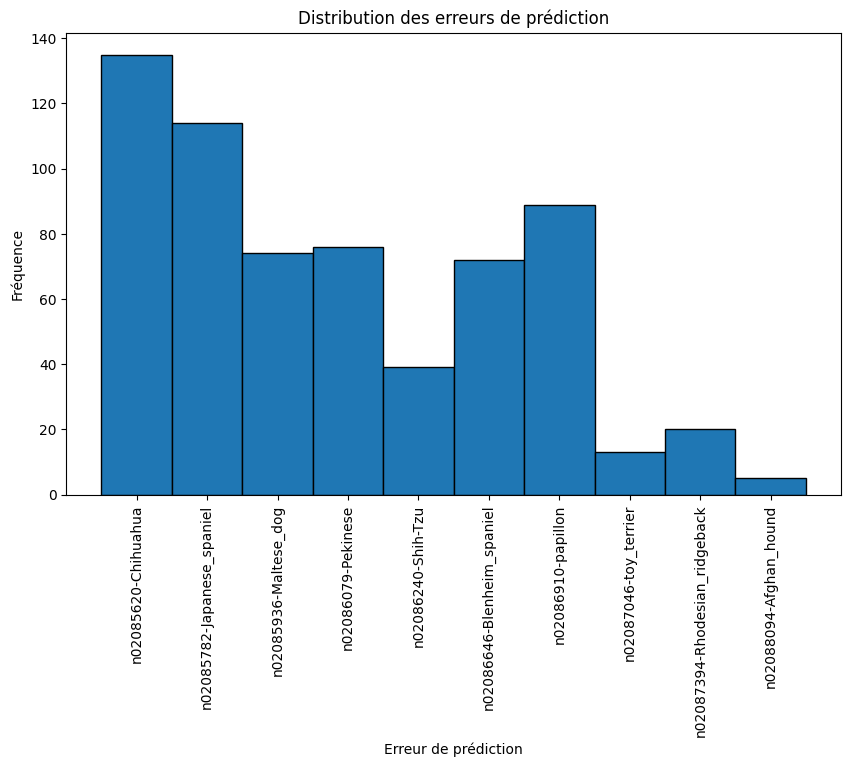

In [32]:
# Histogramme des erreurs de prediction
errors = y_true_classes - y_pred_classes  # Différence entre vraies classes et prédictions

plt.figure(figsize=(10, 6))
plt.hist(errors, bins=np.arange(-0.5, y_test_cat.shape[1] + 0.5, 1), edgecolor='black')
plt.xlabel("Erreur de prédiction")
plt.ylabel("Fréquence")
plt.title("Distribution des erreurs de prédiction")
plt.xticks(range(y_test_cat.shape[1]), label_encoder.classes_, rotation=90) 
plt.show()

Les performances en local, avec seulement 10 races de chiens ne sont pas bonnes. Nous allons switcher vers google colab pour un entrainement avec tout le datset  puis donner notre interpretation